In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [2]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=7c7c69dff6bdc1cdf3195d05082c3cb3a142b4e4760afdc5f46f10151e283892
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [4]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dat.gz")

Downloaded nsfg.py
Downloaded 2002FemResp.dct
Downloaded 2002FemResp.dat.gz


In [5]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [6]:
from nsfg import read_fem_resp

resp = read_fem_resp()

In [7]:
older = resp.query("age >= 25")
num_family = older["numfmhh"]

In [8]:
from empiricaldist import Pmf

pmf_family = Pmf.from_seq(num_family, name="data")

In [9]:
from thinkstats import poisson_pmf

lam = 2.2
ks = np.arange(11)
ps = poisson_pmf(ks, lam)

pmf_poisson = Pmf(ps, ks, name="Poisson model")

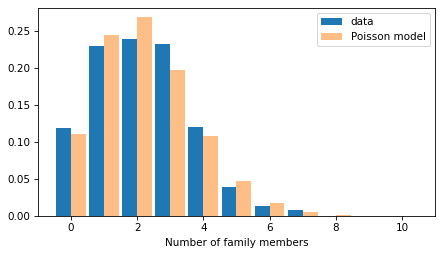

In [10]:
from thinkstats import two_bar_plots

two_bar_plots(pmf_family, pmf_poisson)
decorate(xlabel="Number of family members")

In [11]:
cdf_family = pmf_family.make_cdf()
cdf_poisson = pmf_poisson.make_cdf()

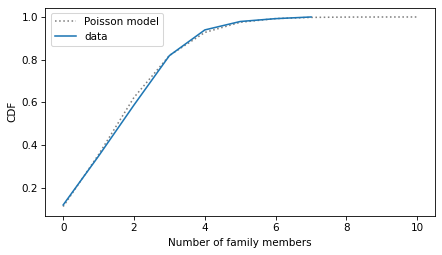

In [12]:
from thinkstats import two_cdf_plots

two_cdf_plots(cdf_poisson, cdf_family)
decorate(xlabel="Number of family members")

In [13]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [14]:
from nsfg import read_fem_preg

preg = read_fem_preg()
birth_weights = preg["totalwgt_lb"].dropna()

In [15]:
from scipy.stats import trimboth
from thinkstats import make_normal_model

trimmed = trimboth(birth_weights, 0.01)
cdf_model = make_normal_model(trimmed)

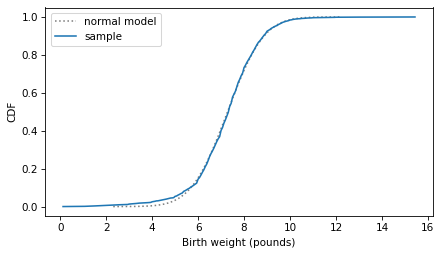

In [16]:
from empiricaldist import Cdf

cdf_birth_weight = Cdf.from_seq(birth_weights, name="sample")
two_cdf_plots(cdf_model, cdf_birth_weight, xlabel="Birth weight (pounds)")

In [17]:
def normal_pdf(xs, mu, sigma):
    """Evaluates the normal probability density function."""
    z = (xs - mu) / sigma
    return np.exp(-(z**2) / 2) / sigma / np.sqrt(2 * np.pi)

In [18]:
m, s = np.mean(trimmed), np.std(trimmed)

In [19]:
low = m - 4 * s
high = m + 4 * s
qs = np.linspace(low, high, 201)
ps = normal_pdf(qs, m, s)

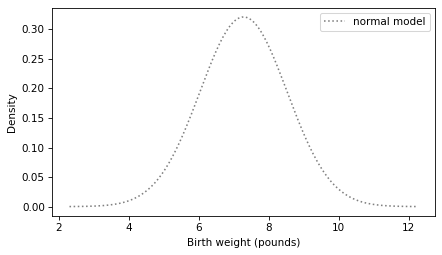

In [20]:
plt.plot(qs, ps, label="normal model", ls=":", color="gray")
decorate(xlabel="Birth weight (pounds)", ylabel="Density")

In [21]:
normal_pdf(m, m, s)

np.float64(0.32093416297880123)

In [22]:
from thinkstats import NormalPdf

pdf_model = NormalPdf(m, s, name="normal model")
pdf_model

NormalPdf(7.280883100022579, 1.2430657948614345, name='normal model')

In [23]:
pdf_model(m)

np.float64(0.32093416297880123)

In [24]:
from scipy.integrate import simpson


def area_under(pdf, low, high):
    qs = np.linspace(low, high, 501)
    ps = pdf(qs)
    return simpson(y=ps, x=qs)

In [25]:
area_under(pdf_model, 2, 12)

np.float64(0.9999158086616793)

In [26]:
area_under(pdf_model, 0, 8.5)

np.float64(0.8366380335513807)

In [27]:
from scipy.stats import norm

norm.cdf(8.5, m, s)

np.float64(0.8366380358092718)

In [28]:
area_under(pdf_model, 6, 8)

np.float64(0.5671317752927691)

In [29]:
norm.cdf(8, m, s) - norm.cdf(6, m, s)

np.float64(0.5671317752921801)

In [30]:
def exponential_cdf(x, lam):
    """Compute the exponential CDF.

    x: float or sequence of floats
    lam: rate parameter

    returns: float or NumPy array of cumulative probability
    """
    return 1 - np.exp(-lam * x)

In [31]:
def exponential_pdf(x, lam):
    """Evaluates the exponential PDF.

    x: float or sequence of floats
    lam: rate parameter

    returns: float or NumPy array of probability density
    """
    return lam * np.exp(-lam * x)

In [32]:
from thinkstats import ExponentialPdf

lam = 6
pdf_expo = ExponentialPdf(lam, name="exponential model")
pdf_expo

ExponentialPdf(6, name='exponential model')

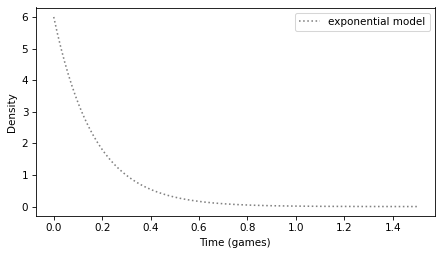

In [33]:
qs = np.linspace(0, 1.5, 201)
pdf_expo.plot(qs, ls=":", color="gray")
decorate(xlabel="Time (games)", ylabel="Density")

In [34]:
area_under(pdf_expo, 0, 1.5)

np.float64(0.999876590779019)

In [35]:
from thinkstats import exponential_cdf

exponential_cdf(7, lam)

np.float64(1.0)

In [36]:
area_under(pdf_expo, 0, 1 / 60)

np.float64(0.09516258196404043)

In [37]:
exponential_cdf(1 / 60, lam)

np.float64(0.09516258196404048)

In [38]:
pmf_birth_weight = Pmf.from_seq(birth_weights, name="data")

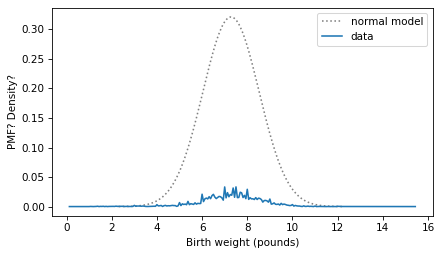

In [39]:
pdf_model.plot(ls=":", color="gray")
pmf_birth_weight.plot()

decorate(xlabel="Birth weight (pounds)", ylabel="PMF? Density?")

In [40]:
pmf_model = pdf_model.make_pmf()

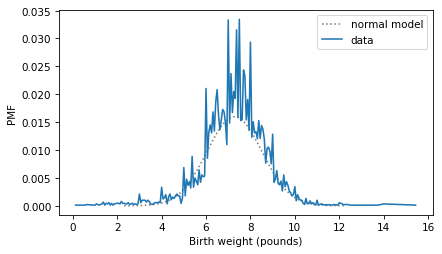

In [41]:
pmf_model.plot(ls=":", color="gray")
pmf_birth_weight.plot()

decorate(xlabel="Birth weight (pounds)", ylabel="PMF")

In [42]:
len(pmf_model), len(pmf_birth_weight)

(201, 184)

In [43]:
# Set the random seed so we get the same results every time
np.random.seed(3)

In [44]:
n = 10
sample = birth_weights.sample(n)

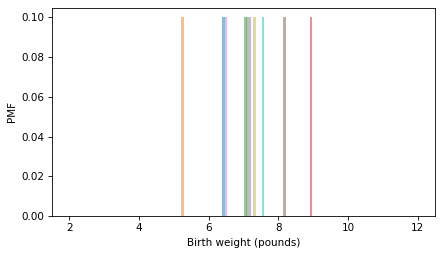

In [45]:
for weight in sample:
    pmf = Pmf.from_seq([weight]) / n
    pmf.bar(width=0.08, alpha=0.5)

xlim = [1.5, 12.5]
decorate(xlabel="Birth weight (pounds)", ylabel="PMF", xlim=xlim)

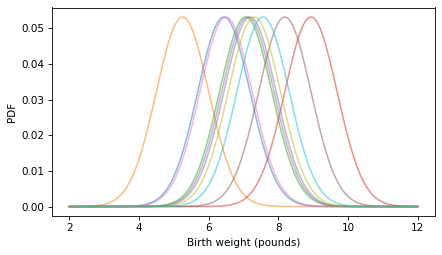

In [46]:
qs = np.linspace(2, 12, 201)

for weight in sample:
    ps = NormalPdf(weight, 0.75)(qs) / n
    plt.plot(qs, ps, alpha=0.5)

decorate(xlabel="Birth weight (pounds)", ylabel="PDF", xlim=xlim)

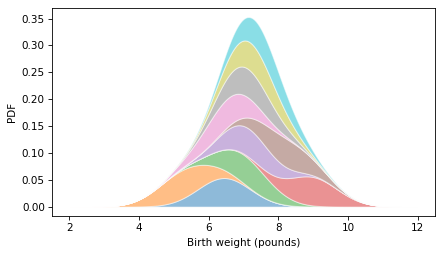

In [47]:
low_ps = np.zeros_like(qs)

for weight in sample:
    ps = NormalPdf(weight, 0.75)(qs) / n
    high_ps = low_ps + ps
    plt.fill_between(qs, low_ps, high_ps, alpha=0.5, lw=1, ec="white")
    low_ps = high_ps

decorate(xlabel="Birth weight (pounds)", ylabel="PDF", xlim=xlim)

In [48]:
from scipy.stats import gaussian_kde

kde = gaussian_kde(birth_weights)

In [49]:
ps = kde(qs)

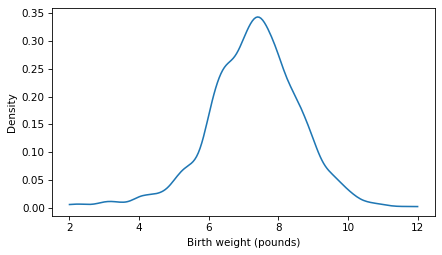

In [50]:
plt.plot(qs, ps)

decorate(xlabel="Birth weight (pounds)", ylabel="Density")

In [51]:
from thinkstats import Pdf

domain = np.min(birth_weights), np.max(birth_weights)
kde_birth_weights = Pdf(kde, domain, name="data")

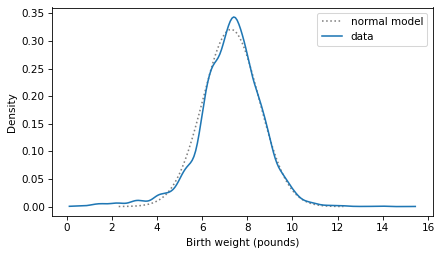

In [52]:
pdf_model.plot(ls=":", color="gray")
kde_birth_weights.plot()

decorate(xlabel="Birth weight (pounds)", ylabel="Density")

In [53]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/babyboom.dat")

Downloaded babyboom.dat


In [54]:
from thinkstats import read_baby_boom

boom = read_baby_boom()
boom.head()

,time,sex,weight_g,minutes
0,5,1,3837,5
1,104,1,3334,64
2,118,2,3554,78
3,155,2,3838,115
4,257,2,3625,177


In [55]:
diffs = boom["minutes"].diff().dropna()

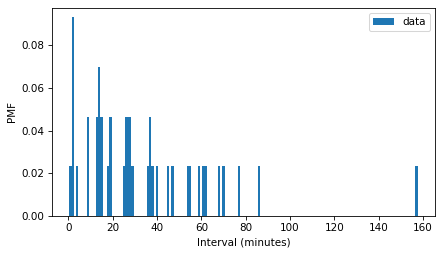

In [56]:
pmf_diffs = Pmf.from_seq(diffs, name="data")
pmf_diffs.bar(width=1)

decorate(xlabel="Interval (minutes)", ylabel="PMF")

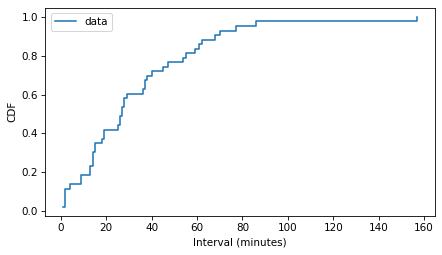

In [57]:
cdf_diffs = pmf_diffs.make_cdf()
cdf_diffs.step()

decorate(xlabel="Interval (minutes)", ylabel="CDF")

In [58]:
pmf_diffs2 = cdf_diffs.make_pmf()

In [59]:
np.allclose(pmf_diffs, pmf_diffs2)

True

In [60]:
kde = gaussian_kde(pmf_diffs.qs, weights=pmf_diffs.ps)

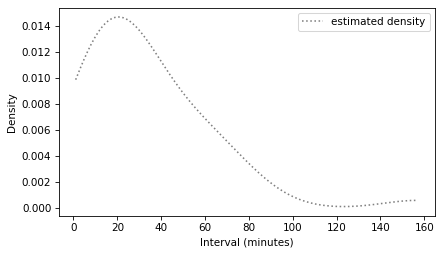

In [61]:
domain = np.min(pmf_diffs.qs), np.max(pmf_diffs.qs)
kde_diffs = Pdf(kde, domain=domain, name="estimated density")

kde_diffs.plot(ls=":", color="gray")
decorate(xlabel="Interval (minutes)", ylabel="Density")

In [62]:
from thinkstats import ExponentialCdf

m = diffs.mean()
lam = 1 / m
cdf_model = ExponentialCdf(lam, name="exponential CDF")

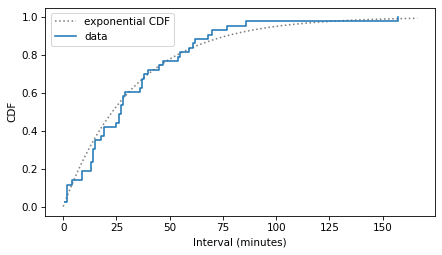

In [63]:
cdf_model.plot(ls=":", color="gray")
cdf_diffs.step()

decorate(xlabel="Interval (minutes)", ylabel="CDF")

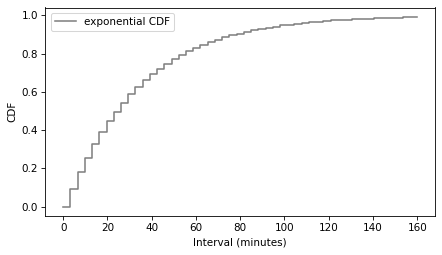

In [64]:
qs = np.linspace(0, 160)
discrete_cdf_model = cdf_model.make_cdf(qs)
discrete_cdf_model.step(color="gray")

decorate(xlabel="Interval (minutes)", ylabel="CDF")

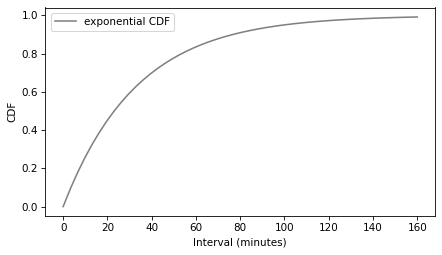

In [65]:
discrete_cdf_model.plot(color="gray")

decorate(xlabel="Interval (minutes)", ylabel="CDF")

In [66]:
import sympy as sp

x = sp.Symbol("x", real=True, positive=True)
λ = sp.Symbol("λ", real=True, positive=True)

cdf = 1 - sp.exp(-λ * x)
cdf

1 - exp(-x*λ)

In [67]:
pdf = sp.diff(cdf, x)
pdf

λ*exp(-x*λ)

In [68]:
sp.integrate(pdf, x)

-exp(-x*λ)

## Exercises

In [69]:
# Exercise 6.1

import numpy as np

# Exponential PDF
def exponential_pdf(x, lam):

    return lam * np.exp(-lam * x)

In [70]:
# Area under PDF using numerical integration

def area_under(lam, a, b, n=1000):

    xs = np.linspace(a, b, n)

    ys = exponential_pdf(xs, lam)

    area = np.trapz(ys, xs)

    return area

In [71]:
# Exponential CDF

def exponential_cdf(x, lam):

    return 1 - np.exp(-lam * x)

In [72]:
# Given rate
lam = 2.5

# ------------------------------------------------
# Probability first goal occurs before half-time
# ------------------------------------------------

# Using PDF + area
prob_first_half_pdf = area_under(lam, 0, 0.5)

print("First half probability using PDF =", prob_first_half_pdf)

# Using CDF
prob_first_half_cdf = exponential_cdf(0.5, lam)

print("First half probability using CDF =", prob_first_half_cdf)

First half probability using PDF = 0.7134952962289138
First half probability using CDF = 0.7134952031398099


/tmp/ipykernel_2326/186126417.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(ys, xs)


In [73]:
# ------------------------------------------------
# Probability first goal occurs in second half
# ------------------------------------------------

# Using PDF + area
prob_second_half_pdf = area_under(lam, 0.5, 1)

print("Second half probability using PDF =", prob_second_half_pdf)

# Using CDF
prob_second_half_cdf = exponential_cdf(1, lam) - exponential_cdf(0.5, lam)

print("Second half probability using CDF =", prob_second_half_cdf)

Second half probability using PDF = 0.20441982490676613
Second half probability using CDF = 0.2044197982362913


/tmp/ipykernel_2326/186126417.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(ys, xs)


In [74]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/CDBRFS08.ASC.gz")

Downloaded CDBRFS08.ASC.gz


In [75]:
from thinkstats import read_brfss

brfss = read_brfss()
male = brfss.query("sex == 1")
heights = male["htm3"].dropna()

In [76]:
from scipy.stats import trimboth

trimmed = trimboth(heights, 0.01)
m, s = np.mean(trimmed), np.std(trimmed)
m, s

(np.float64(178.10278947124948), np.float64(7.017054887136004))

In [77]:
from thinkstats import NormalCdf

cdf_normal_model = NormalCdf(m, s, name='normal model')

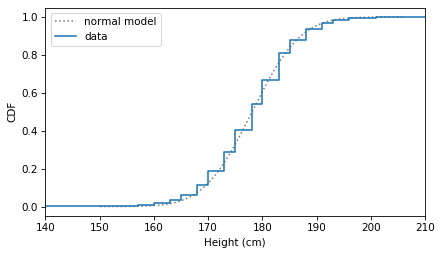

In [78]:
cdf_height = Cdf.from_seq(heights, name="data")
cdf_normal_model.plot(ls=":", color="gray")
cdf_height.step()

xlim = [140, 210]
decorate(xlabel="Height (cm)", ylabel="CDF", xlim=xlim)

In [79]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import gaussian_kde
from scipy.stats import norm

from empiricaldist import Cdf

In [80]:
# Download BRFSS dataset

!wget -nc https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/data/CDBRFS08.ASC.gz

File ‘CDBRFS08.ASC.gz’ already there; not retrieving.



In [81]:
# Read male heights from BRFSS

colspecs = [(123, 127), (142, 143)]
names = ['height', 'sex']

brfss = pd.read_fwf(
    'CDBRFS08.ASC.gz',
    colspecs=colspecs,
    names=names,
    compression='gzip'
)

# Select males only
male = brfss[brfss['sex'] == 1]

# Clean heights
heights = male['height']

heights = heights.replace(9999, np.nan)

heights = heights.dropna()

heights = heights[(heights > 100) & (heights < 250)]

heights = np.array(heights)

print("Number of male heights =", len(heights))

Number of male heights = 25


In [82]:
# Mean and standard deviation

m = heights.mean()
s = heights.std()

print("Mean =", m)
print("Std =", s)

Mean = 164.4
Std = 9.024411338142782


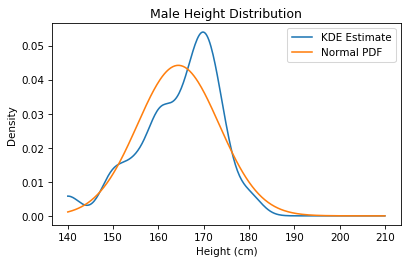

In [83]:
# ------------------------------------------------
# KDE estimate of PDF
# ------------------------------------------------

kde = gaussian_kde(heights, bw_method=0.3)

xs = np.linspace(140, 210, 300)

kde_pdf = kde(xs)

# Normal PDF
normal_pdf = norm.pdf(xs, loc=m, scale=s)

# Plot comparison
plt.plot(xs, kde_pdf, label='KDE Estimate')

plt.plot(xs, normal_pdf, label='Normal PDF')

plt.xlabel("Height (cm)")
plt.ylabel("Density")
plt.title("Male Height Distribution")

plt.legend()

plt.show()

In [84]:
# ------------------------------------------------
# Normal PDF + area_under
# ------------------------------------------------

def normal_pdf(x, mu, sigma):

    return norm.pdf(x, loc=mu, scale=sigma)

In [85]:
# Numerical integration

def area_under_normal(mu, sigma, a, b, n=1000):

    xs = np.linspace(a, b, n)

    ys = normal_pdf(xs, mu, sigma)

    area = np.trapz(ys, xs)

    return area

In [86]:
# Fraction between 178 and 185 cm using PDF

prob_pdf = area_under_normal(m, s, 178, 185)

print("Fraction using Normal PDF =", prob_pdf)

Fraction using Normal PDF = 0.0546782221136598


/tmp/ipykernel_2326/1802592946.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(ys, xs)


In [87]:
# ------------------------------------------------
# Using Normal CDF
# ------------------------------------------------

prob_cdf = norm.cdf(185, loc=m, scale=s) - norm.cdf(178, loc=m, scale=s)

print("Fraction using Normal CDF =", prob_cdf)

Fraction using Normal CDF = 0.054678215790575635


In [89]:
# ------------------------------------------------
# Using empirical CDF
# ------------------------------------------------

cdf_height = Cdf.from_seq(heights)

# Fraction between 178 and 185 cm
empirical_fraction = cdf_height(185) - cdf_height(178)

print("Fraction using empirical CDF =", empirical_fraction)

Fraction using empirical CDF = 0.040000000000000036
